In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
cadastrados = pd.read_csv('https://github.com/alura-tech/alura-tech-pos-data-science-credit-scoring-streamlit/blob/main/dados/clientes_cadastrados.csv?raw=True')

HTTPError: HTTP Error 429: Too Many Requests

In [ ]:
cadastrados.head()

,429: Too Many Requests
For more on scraping GitHub and how it may affect your rights,please review our Terms of Service (https://d...


In [ ]:
cadastrados.shape

(438557, 18)

In [ ]:
cadastrados['ID_Cliente'].value_counts()

ID_Cliente
7137299    2
7702238    2
7282535    2
7243768    2
7050948    2
          ..
5690727    1
6621262    1
6621261    1
6621260    1
6842885    1
Name: count, Length: 438510, dtype: int64

In [ ]:
id_repetidos = cadastrados[cadastrados['ID_Cliente'].duplicated(keep=False)]

In [ ]:
df_cadastrados_limpo = cadastrados.drop(id_repetidos.index)

In [ ]:
df_cadastrados_limpo['ID_Cliente'].value_counts()

ID_Cliente
5008804    1
6147691    1
6147689    1
6147688    1
6147685    1
          ..
6093492    1
5690720    1
6538938    1
6538937    1
6842885    1
Name: count, Length: 438463, dtype: int64

In [ ]:
df_cadastrados_limpo.isnull().sum().sort_values(ascending=False)

Ocupacao                 134177
ID_Cliente                    0
Genero                        0
Tem_email                     0
Tem_telefone_fixo             0
Tem_telefone_trabalho         0
Tem_celular                   0
Anos_empregado                0
Idade                         0
Moradia                       0
Estado_civil                  0
Grau_escolaridade             0
Categoria_de_renda            0
Rendimento_anual              0
Qtd_filhos                    0
Tem_casa_propria              0
Tem_carro                     0
Tamanho_familia               0
dtype: int64

In [ ]:
df_cadastrados_limpo['Ocupacao'].unique()

array([nan, 'Segurança', 'Vendas', 'Contabilidade', 'Construção Civil',
       'Gerência', 'Motorista', 'Equipe principal', 'Alta tecnologia',
       'Limpeza', 'Serviço privado', 'Cozinha', 'Baixa qualificação',
       'Medicina', 'Secretariado', 'Garçom', 'RH', 'Corretor imobiliário',
       'TI'], dtype=object)

In [ ]:
df_cadastrados_limpo['Ocupacao'].fillna(value='Outro',inplace=True)

In [ ]:
df_cadastrados_limpo.isnull().sum().sort_values(ascending=False)

ID_Cliente               0
Genero                   0
Ocupacao                 0
Tem_email                0
Tem_telefone_fixo        0
Tem_telefone_trabalho    0
Tem_celular              0
Anos_empregado           0
Idade                    0
Moradia                  0
Estado_civil             0
Grau_escolaridade        0
Categoria_de_renda       0
Rendimento_anual         0
Qtd_filhos               0
Tem_casa_propria         0
Tem_carro                0
Tamanho_familia          0
dtype: int64

In [ ]:
df_cadastrados_limpo.nunique().sort_values(ascending=False)

ID_Cliente               438463
Idade                     16379
Anos_empregado             9406
Rendimento_anual            866
Ocupacao                     19
Tamanho_familia              13
Qtd_filhos                   12
Moradia                       6
Categoria_de_renda            5
Grau_escolaridade             5
Estado_civil                  5
Genero                        2
Tem_casa_propria              2
Tem_telefone_trabalho         2
Tem_telefone_fixo             2
Tem_email                     2
Tem_carro                     2
Tem_celular                   1
dtype: int64

In [ ]:
df_cadastrados_limpo.drop('Genero', axis=1, inplace=True)

In [ ]:
df_cadastrados_limpo.drop('Tem_celular', axis=1, inplace=True)

In [ ]:
df_cadastrados_limpo.columns

Index(['ID_Cliente', 'Tem_carro', 'Tem_casa_propria', 'Qtd_filhos',
       'Rendimento_anual', 'Categoria_de_renda', 'Grau_escolaridade',
       'Estado_civil', 'Moradia', 'Idade', 'Anos_empregado',
       'Tem_telefone_trabalho', 'Tem_telefone_fixo', 'Tem_email', 'Ocupacao',
       'Tamanho_familia'],
      dtype='object')

In [ ]:
df_cadastrados_limpo['Tem_carro'].unique()

array(['Y', 'N'], dtype=object)

In [ ]:
df_cadastrados_limpo['Tem_casa_propria'].unique()

array(['Y', 'N'], dtype=object)

In [ ]:
df_cadastrados_limpo['Tem_telefone_trabalho'].unique()

array([1, 0], dtype=int64)

In [ ]:
df_cadastrados_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438463 entries, 0 to 438556
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID_Cliente             438463 non-null  int64  
 1   Tem_carro              438463 non-null  object 
 2   Tem_casa_propria       438463 non-null  object 
 3   Qtd_filhos             438463 non-null  int64  
 4   Rendimento_anual       438463 non-null  float64
 5   Categoria_de_renda     438463 non-null  object 
 6   Grau_escolaridade      438463 non-null  object 
 7   Estado_civil           438463 non-null  object 
 8   Moradia                438463 non-null  object 
 9   Idade                  438463 non-null  int64  
 10  Anos_empregado         438463 non-null  int64  
 11  Tem_telefone_trabalho  438463 non-null  int64  
 12  Tem_telefone_fixo      438463 non-null  int64  
 13  Tem_email              438463 non-null  int64  
 14  Ocupacao               438463 non-null  o

In [ ]:
df_cadastrados_limpo['Tem_carro'] = df_cadastrados_limpo['Tem_carro'].replace(['Y', 'N'], [1, 0])

In [ ]:
df_cadastrados_limpo['Tem_casa_propria'] = df_cadastrados_limpo['Tem_casa_propria'].replace(['Y', 'N'], [1, 0])

In [ ]:
df_cadastrados_limpo.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,0,0,Outro,2.0
1,5008805,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,0,0,Outro,2.0
2,5008806,1,1,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,-21474,-1134,0,0,0,Segurança,2.0
3,5008808,0,1,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,0,1,1,Vendas,1.0
4,5008809,0,1,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,0,1,1,Vendas,1.0


In [ ]:
df_cadastrados_limpo['Idade'] = - df_cadastrados_limpo['Idade'] / 365.2425

In [ ]:
df_cadastrados_limpo['Anos_empregado'] = - df_cadastrados_limpo['Anos_empregado'] / 365.2425

In [ ]:
df_cadastrados_limpo['Anos_empregado'].value_counts()

Anos_empregado
-1000.001369    75314
 0.596864         262
 4.594208         251
 0.681739         241
 2.677673         240
                ...  
 37.041144          1
 27.989623          1
 24.413917          1
 31.291539          1
 22.190736          1
Name: count, Length: 9406, dtype: int64

In [ ]:
df_cadastrados_limpo.loc[df_cadastrados_limpo['Anos_empregado'] < 0, 'Anos_empregado'] = 0

In [ ]:
df_cadastrados_limpo['Anos_empregado'].value_counts()

Anos_empregado
0.000000     75314
0.596864       262
4.594208       251
0.681739       241
2.677673       240
             ...  
37.041144        1
27.989623        1
24.413917        1
31.291539        1
22.190736        1
Name: count, Length: 9406, dtype: int64

In [ ]:
df_cadastrados_limpo.dtypes

ID_Cliente                 int64
Tem_carro                  int64
Tem_casa_propria           int64
Qtd_filhos                 int64
Rendimento_anual         float64
Categoria_de_renda        object
Grau_escolaridade         object
Estado_civil              object
Moradia                   object
Idade                    float64
Anos_empregado           float64
Tem_telefone_trabalho      int64
Tem_telefone_fixo          int64
Tem_email                  int64
Ocupacao                  object
Tamanho_familia          float64
dtype: object

<AxesSubplot: >

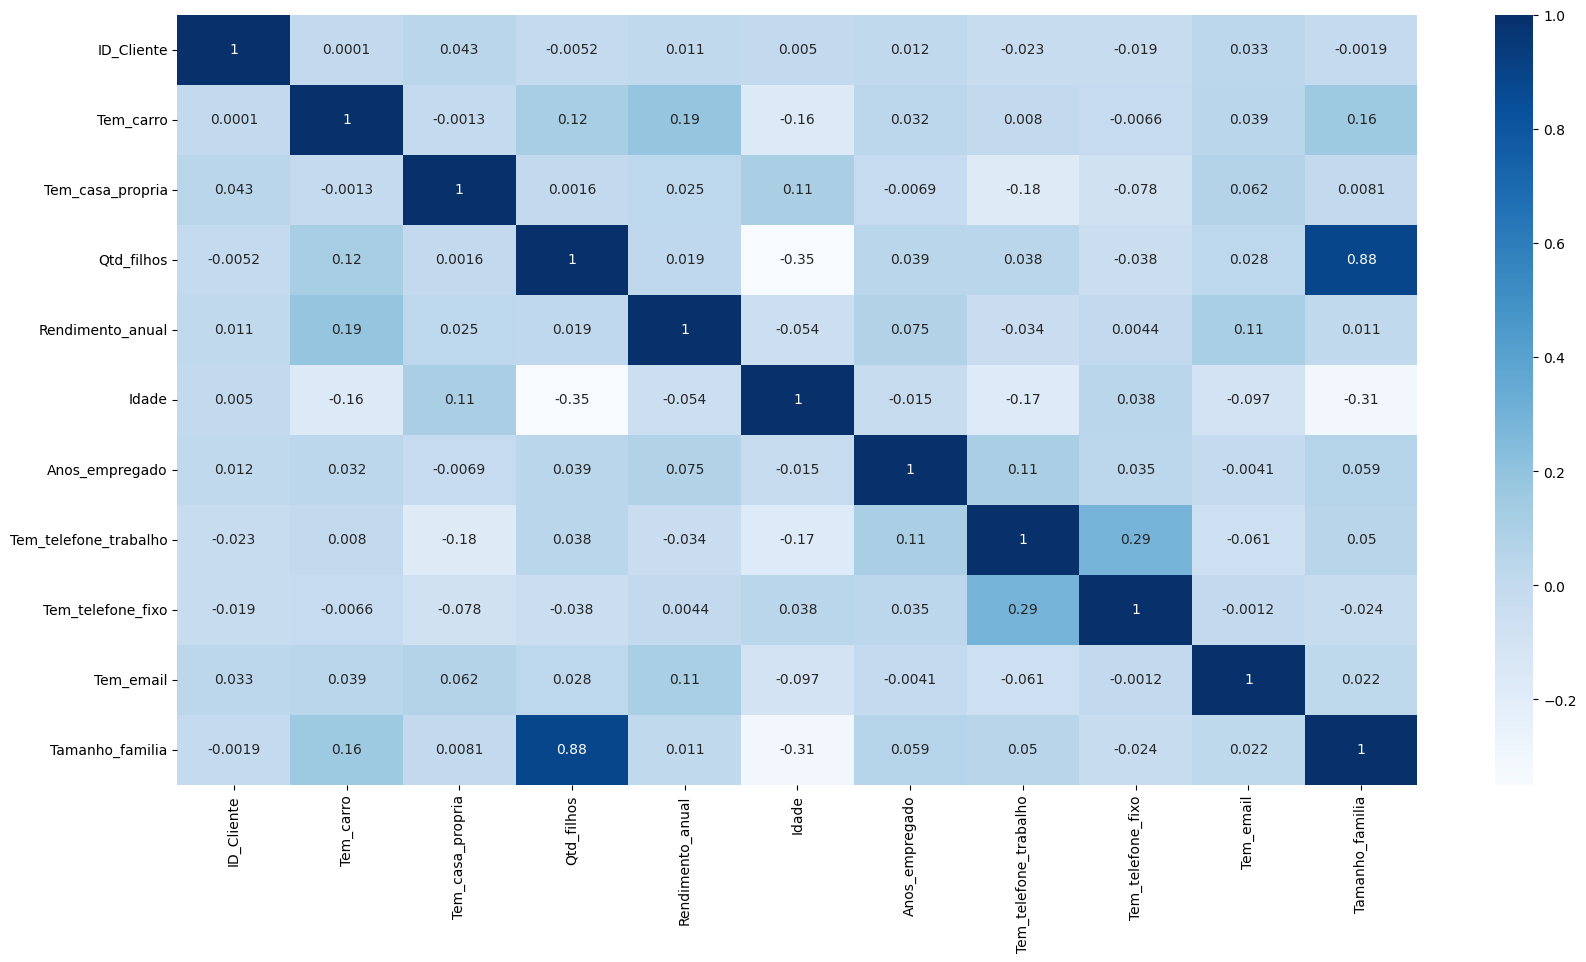

In [ ]:
corr = df_cadastrados_limpo.select_dtypes(include=['number']).corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, cmap='Blues', annot=True)

In [ ]:
df_cadastrados_limpo.drop(['Qtd_filhos'], axis=1, inplace=True)

In [ ]:
df_cadastrados_limpo.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,1,1,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,32.868574,12.435574,1,0,0,Outro,2.0
1,5008805,1,1,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,32.868574,12.435574,1,0,0,Outro,2.0
2,5008806,1,1,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,58.793815,3.104787,0,0,0,Segurança,2.0
3,5008808,0,1,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,52.321403,8.353354,0,1,1,Vendas,1.0
4,5008809,0,1,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,52.321403,8.353354,0,1,1,Vendas,1.0


In [ ]:
df_cadastrados_limpo = df_cadastrados_limpo[['ID_Cliente', 'Tem_carro', 'Tem_casa_propria', 'Tem_telefone_trabalho', 'Tem_telefone_fixo', 'Tem_email', 'Tamanho_familia'
                                             ,'Rendimento_anual', 'Idade', 'Anos_empregado', 'Categoria_de_renda', 'Grau_escolaridade', 'Estado_civil', 'Moradia', 'Ocupacao']]

In [ ]:
df_cadastrados_limpo.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Tamanho_familia,Rendimento_anual,Idade,Anos_empregado,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Ocupacao
0,5008804,1,1,1,0,0,2.0,427500.0,32.868574,12.435574,Empregado,Ensino superior,União-estável,Apartamento alugado,Outro
1,5008805,1,1,1,0,0,2.0,427500.0,32.868574,12.435574,Empregado,Ensino superior,União-estável,Apartamento alugado,Outro
2,5008806,1,1,0,0,0,2.0,112500.0,58.793815,3.104787,Empregado,Ensino médio,Casado,Casa/apartamento próprio,Segurança
3,5008808,0,1,0,1,1,1.0,270000.0,52.321403,8.353354,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,Vendas
4,5008809,0,1,0,1,1,1.0,270000.0,52.321403,8.353354,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,Vendas


In [ ]:
df_cadastrados_limpo['Categoria_de_renda'].value_counts(normalize=True)*100

Categoria_de_renda
Empregado              51.557144
Associado comercial    22.972520
Pensionista            17.214223
Servidor público        8.252236
Estudante               0.003877
Name: proportion, dtype: float64

In [ ]:
aprovados = pd.read_csv('https://github.com/alura-tech/alura-tech-pos-data-science-credit-scoring-streamlit/blob/main/dados/clientes_aprovados.csv?raw=True')

NameError: name 'pd' is not defined

In [ ]:
aprovados.info()

In [ ]:
aprovados.head()

NameError: name 'aprovados' is not defined

In [ ]:
aprovados.query('ID_Cliente == 5001712')

In [ ]:
aprovados.query('ID_Cliente == 5001711')

In [ ]:
aprovados.Faixa_atraso.value_counts()

In [ ]:
df_registros_credito_agrupados_ID = aprovados.groupby('ID_Cliente')
ser_abertura = df_registros_credito_agrupados_ID.apply(lambda x: min(x['Mes_referencia']))
ser_abertura.name = 'Abertura'
ser_abertura.head

In [ ]:
df_clientes_aprovados = aprovados.merge(ser_abertura, on='ID_Cliente')
df_clientes_aprovados.head()

In [ ]:
ser_final = df_registros_credito_agrupados_ID.apply(lambda x: max(x['Mes_referencia']))
ser_final.name = 'Final'
ser_final

In [ ]:
df_clientes_aprovados = df_clientes_aprovados.merge(ser_final, on='ID_Cliente')
df_clientes_aprovados.head()

In [ ]:
df_clientes_aprovados['Janela'] = df_clientes_aprovados['Final'] - df_clientes_aprovados['Abertura']
df_clientes_aprovados.head()

In [ ]:
df_clientes_aprovados['MOB'] = df_clientes_aprovados['Mes_referencia'] - df_clientes_aprovados['Abertura']

In [ ]:
df_clientes_aprovados.head()

In [ ]:
df_clientes_aprovados['Faixa_atraso'].unique()

In [ ]:
dict_faixa_atraso_ind = {
  'nenhum empréstimo' :0, 'pagamento realizado' :1, '1-29 dias' :2, '30-59 dias' :3, '60-89 dias' :4, '90-119 dias' :5, '120-149 dias' :6, '>150 dias' :7
}

In [ ]:
df_clientes_aprovados['Ind_Faixa_atraso'] = df_clientes_aprovados['Faixa_atraso'].map(dict_faixa_atraso_ind)
df_clientes_aprovados.head()

In [ ]:
df_clientes_aprovados['Mau'] = df_clientes_aprovados.apply(lambda x: 1 if x['Ind_Faixa_atraso'] > 3 else 0, axis=1)

In [ ]:
df_clientes_aprovados.head()

In [ ]:
df_registros_creditos_ID = df_clientes_aprovados[['ID_Cliente', 'Abertura', 'Final', 'Janela']].groupby('ID_Cliente').apply(lambda x: x.iloc[0]).reset_index(drop=True)

In [ ]:
df_registros_creditos_ID

In [1]:
df_denominador = df_registros_creditos_ID.groupby('Abertura').apply(lambda x: x['ID_Cliente'].count()).reset_index()
df_denominador.columns = ['Abertura', 'Qtd_Cliente']
df_denominador

NameError: name 'df_registros_creditos_ID' is not defined